# 03 — Imbalance Handling

Compare four strategies for dealing with the 0.17% fraud rate:
SMOTE, random undersampling, class weights, and SMOTE+Tomek.
Winner (highest PR-AUC) is saved and becomes the baseline for notebook 04.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve,
    precision_score, recall_score, f1_score,
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE    = 0.2
MODELS_PATH  = Path('../outputs/models')
FIGURES_PATH = Path('../outputs/figures')
MODELS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\New User\AppData\Roaming\Pyth

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\New User\AppData\Roaming\Pyth

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## 1. Load & prep (same pipeline as notebook 02)

In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')
df['log_amount']  = np.log1p(df['Amount'])
df['hour_of_day'] = (df['Time'] // 3600) % 24
df = df.drop(columns=['Time', 'Amount'])

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train fraud: {y_train.sum()} / {len(y_train):,}")
print(f"Test  fraud: {y_test.sum()} / {len(y_test):,}")

Train fraud: 394 / 227,845
Test  fraud: 98 / 56,962


## 2. Define strategies

Each strategy wraps a `StandardScaler` + resampler + `LogisticRegression` into
an imbalanced-learn `Pipeline` so resampling only ever sees training folds.

In [3]:
strategies = {
    'class_weight_balanced': ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
                      class_weight='balanced', max_iter=1000,
                      random_state=RANDOM_STATE)),
    ]),
    'random_undersample': ImbPipeline([
        ('scaler',  StandardScaler()),
        ('resample', RandomUnderSampler(random_state=RANDOM_STATE)),
        ('clf',      LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'smote': ImbPipeline([
        ('scaler',  StandardScaler()),
        ('resample', SMOTE(random_state=RANDOM_STATE)),
        ('clf',      LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'smote_tomek': ImbPipeline([
        ('scaler',  StandardScaler()),
        ('resample', SMOTETomek(random_state=RANDOM_STATE)),
        ('clf',      LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
}

print(f"{len(strategies)} strategies defined")

4 strategies defined


## 3. Evaluate each strategy

Fit on full training set, score on held-out test set.
PR-AUC is the primary metric — accuracy is meaningless at 0.17% fraud rate.

In [4]:
results      = {}
fitted_models = {}

for name, pipeline in strategies.items():
    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    prauc  = average_precision_score(y_test, y_prob)
    results[name]       = prauc
    fitted_models[name] = (pipeline, y_prob)
    print(f"{name:30s}  PR-AUC = {prauc:.4f}")

best       = max(results, key=results.get)
best_model = fitted_models[best][0]
best_prob  = fitted_models[best][1]
print(f"\nBest strategy: {best}  (PR-AUC={results[best]:.4f})")

class_weight_balanced           PR-AUC = 0.7129
random_undersample              PR-AUC = 0.6099
smote                           PR-AUC = 0.7186
smote_tomek                     PR-AUC = 0.7186

Best strategy: smote  (PR-AUC=0.7186)


## 4. PR-AUC comparison bar chart

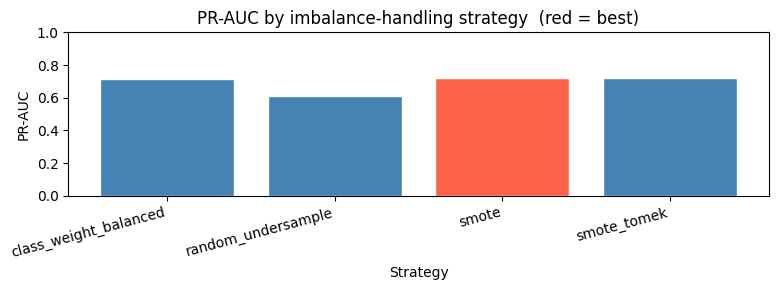

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))
colors = ['tomato' if k == best else 'steelblue' for k in results]
ax.bar(results.keys(), results.values(), color=colors, edgecolor='white')
ax.set_ylabel('PR-AUC')
ax.set_xlabel('Strategy')
ax.set_title('PR-AUC by imbalance-handling strategy  (red = best)')
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. PR curves — all strategies overlaid

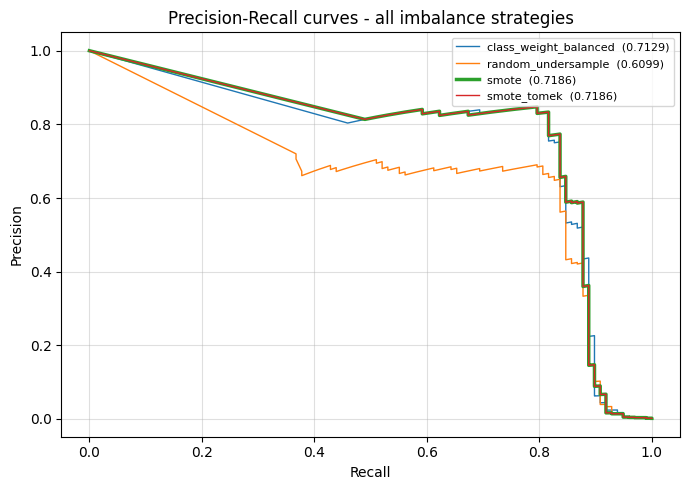

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, (_, y_prob) in fitted_models.items():
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
    lw = 2.5 if name == best else 1.0
    ax.plot(rec_c, prec_c, lw=lw, label=f"{name}  ({results[name]:.4f})")
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves - all imbalance strategies')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Confusion matrix — best model at threshold 0.5

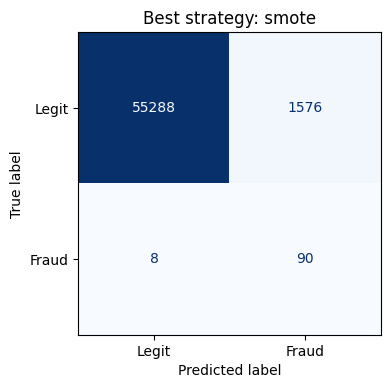

Fraud caught (TP) : 90   Precision : 0.0540
Fraud missed (FN) : 8   Recall    : 0.9184
False alarms (FP) : 1576   F1        : 0.1020
Correct legit (TN): 55,288


In [7]:
y_pred = (best_prob >= 0.5).astype(int)
cm     = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Best strategy: {best}')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
prec_best = precision_score(y_test, y_pred)
rec_best  = recall_score(y_test, y_pred)
f1_best   = f1_score(y_test, y_pred)
print(f"Fraud caught (TP) : {tp}   Precision : {prec_best:.4f}")
print(f"Fraud missed (FN) : {fn}   Recall    : {rec_best:.4f}")
print(f"False alarms (FP) : {fp}   F1        : {f1_best:.4f}")
print(f"Correct legit (TN): {tn:,}")

## 7. Save best model and results

In [8]:
joblib.dump(best_model, MODELS_PATH / 'best_imbalance_model.pkl')
joblib.dump(results,    MODELS_PATH / 'imbalance_results.pkl')
print(f"Saved: outputs/models/best_imbalance_model.pkl  ({best})")
print(f"Saved: outputs/models/imbalance_results.pkl")

print("\n" + "=" * 55)
print("IMBALANCE HANDLING SUMMARY")
print("=" * 55)
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    marker = " <- best" if name == best else ""
    print(f"  {name:30s}  PR-AUC={score:.4f}{marker}")
print(f"\n  Winner: {best}  PR-AUC={results[best]:.4f}")
print(f"  Fraud caught  : {tp} / {y_test.sum()} ({tp/y_test.sum()*100:.1f}%)")
print(f"  Fraud missed  : {fn}")
print(f"\nNext: notebook 04 - replace logistic regression with XGBoost + Optuna tuning.")
print(f"Target to beat: PR-AUC {results[best]:.4f}")
print("=" * 55)

Saved: outputs/models/best_imbalance_model.pkl  (smote)
Saved: outputs/models/imbalance_results.pkl

IMBALANCE HANDLING SUMMARY
  smote                           PR-AUC=0.7186 <- best
  smote_tomek                     PR-AUC=0.7186
  class_weight_balanced           PR-AUC=0.7129
  random_undersample              PR-AUC=0.6099

  Winner: smote  PR-AUC=0.7186
  Fraud caught  : 90 / 98 (91.8%)
  Fraud missed  : 8

Next: notebook 04 - replace logistic regression with XGBoost + Optuna tuning.
Target to beat: PR-AUC 0.7186
